## Logistic Regressor

Come primo passo, carichiamo le librerie e il dataset, eliminiamo le variabili id_participant e le variabili riguardanti l'occupazione, dato che la prima variabile è semplicemente un id, mentre la seconda abbiamo visto durante la PCA che è una variabile rumorosa.

In [27]:
import importlib
import commons
importlib.reload(commons)

import pandas as pd
from commons import prepare_train_test, plot_confusion_matrix, plot_logistic_coefficients

In [32]:
df = pd.read_csv('../df_encoded.csv')
# Identifico le colonne numeriche da lasciare, eliminando ll'identity
df = df.drop([ "participant_id"], axis=1)

print(df.shape)
X = df.drop("side_effects", axis=1)
y = df['side_effects']

scaler, X_train, y_train, X_test, y_test = prepare_train_test(X,y)

(500, 11)


Decidiamo di fare una Gridsearch Cross Validation usando diversi tipi di penalty.
- L2, basato sulla regressione di Ridge: lo scopo di questa penalty diminuisce i coefficienti più rumororsi facendo tenderli verso lo zero, senza eliminarli: è ideale per casi di multicollinearità, che però non dovrebbero essere presenti
- L1, basato sulla regressione di Lasso: a differenza della L1, la L2 azzera alcuni coefficienti, portando quindi ad una riduzione delle feature automatica

In [33]:
from sklearn.metrics import f1_score, classification_report, make_scorer
import warnings
warnings.filterwarnings("ignore", message="Inconsistent values*")
warnings.filterwarnings("ignore", category=FutureWarning)
from commons import logistic_model_selection

grid, best_params, best_score = logistic_model_selection(X_train, y_train)

y_pred = grid.predict(X_test)

train_f1 = f1_score(y_train, grid.predict(X_train), average='macro')
test_f1 = f1_score(y_test, y_pred, average='macro')

print(f"\nF1 score sul Train Set: {train_f1:.4f}")
print(f"F1 score sul Test Set: {test_f1:.4f}")

print("\nBest params:", best_params)
print("Best CV score:", best_score)

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

F1 score sul Train Set: 0.4927
F1 score sul Test Set: 0.4163

Best params: {'C': np.float64(10.0), 'class_weight': None, 'penalty': 'l1', 'solver': 'saga'}
Best CV score: 0.4065852644532454

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.30      0.40      0.34        15
           1       0.29      0.25      0.27        20
           2       0.67      0.42      0.51        24
           3       0.50      0.59      0.54        41

    accuracy                           0.45       100
   macro avg       0.44      0.41      0.42       100
weighted avg       0.47      0.45      0.45       100



Si vede che la performance è insoddisfacente; il modello impara poco e generalizza male e ha anche forti problemi strutturali, come si vede dallo score della cross validation, anche esso molto basso.

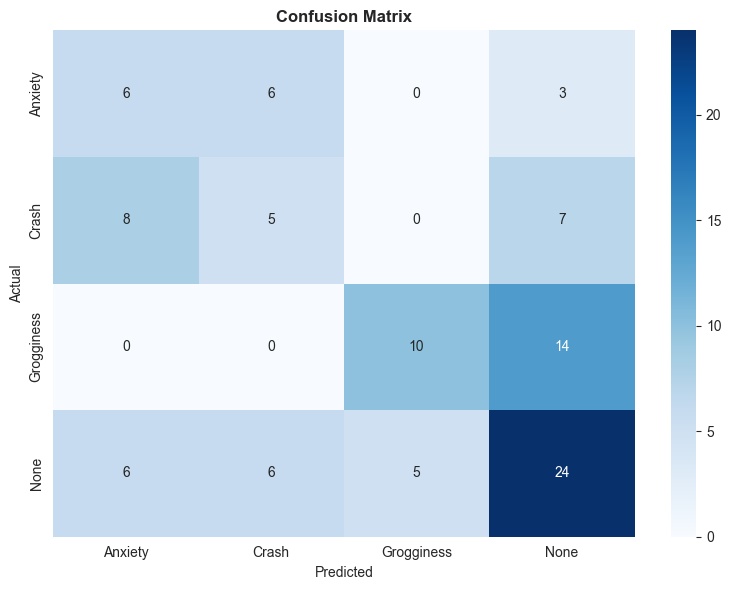

In [34]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
class_labels = ['Anxiety', 'Crash', 'Grogginess', 'None']
plot_confusion_matrix(cm, class_labels, title="Confusion Matrix")

Si vede che l'unica classe che il modello riesce a riconoscere è la classe "None", che tuttavia è quella più frequente. Per una maggiore interpretabilità, provo a studiare la posneg correlation per ciascuna delle classi. Per semplicità, scrivo una legenda per le varie classi:
 - 0 = Anxiety
- 1 = Crash
- 2 = Grogginess
- 3 = None

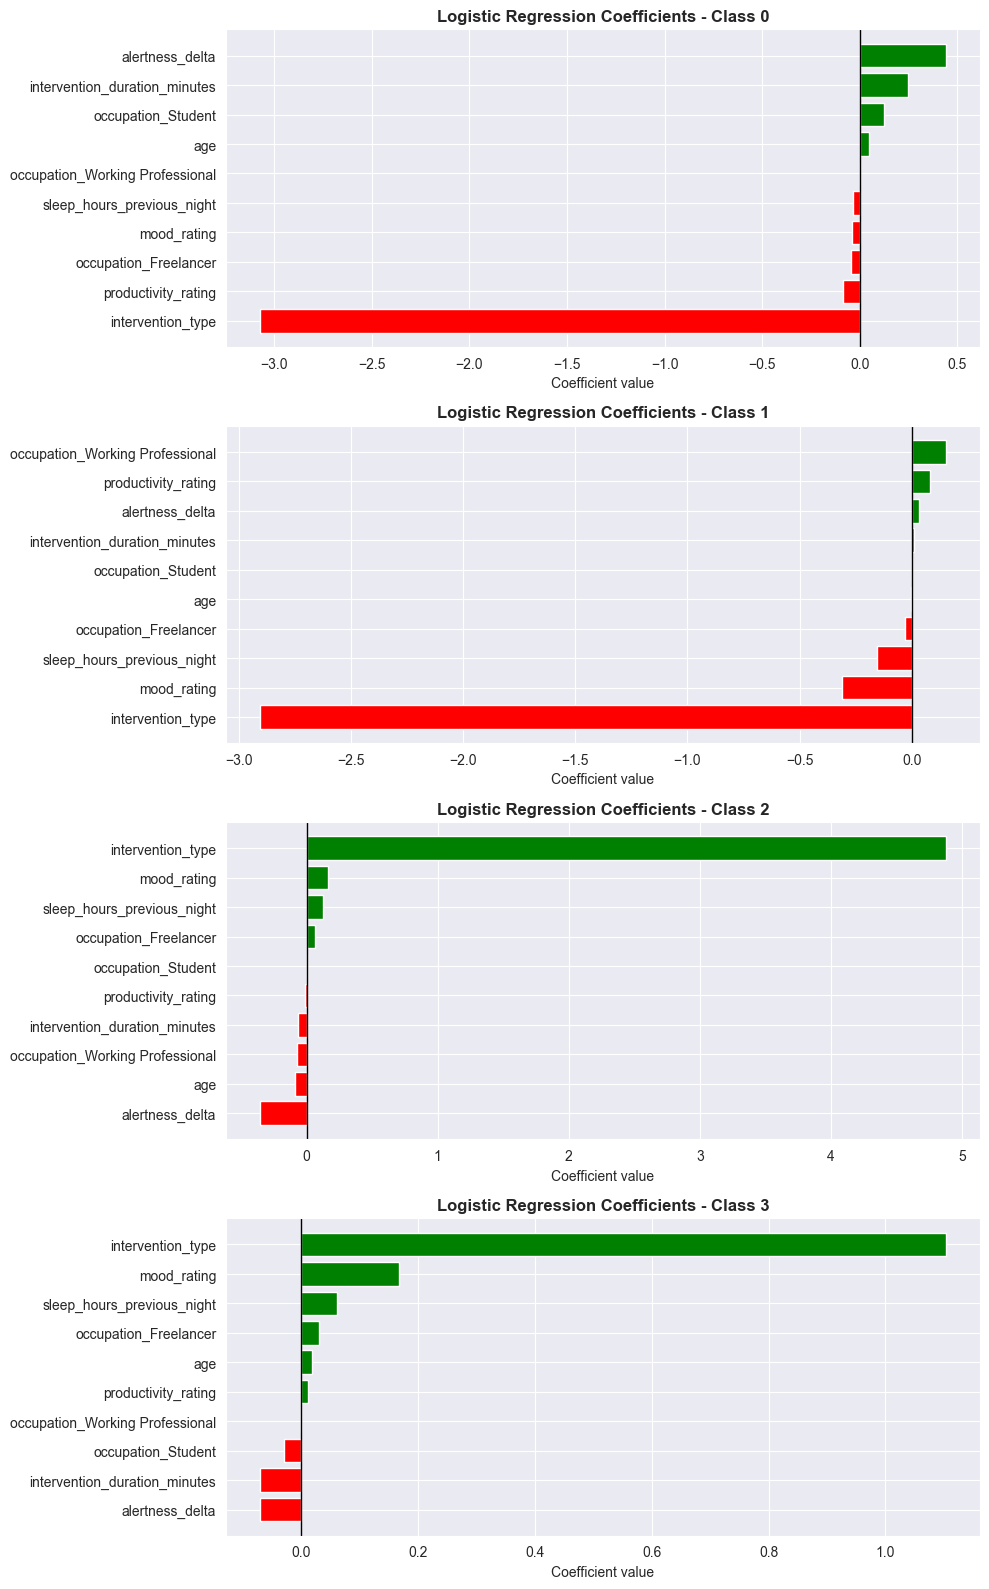

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# prendo il modello migliore dal GridSearch
best_model = grid.best_estimator_

# estraggo il nome delle features
X_train_raw = pd.DataFrame(scaler.inverse_transform(X_train), columns=X.columns)
feature_names = X_train_raw.columns

# e coefficienti del modello
coefs = best_model.coef_

# e le labels
classes = best_model.classes_
best_model = grid.best_estimator_
X_train_raw = pd.DataFrame(scaler.inverse_transform(X_train), columns=X.columns)
feature_names = X_train_raw.columns
coefs = best_model.coef_
classes = best_model.classes_

plot_logistic_coefficients(coefs, feature_names, classes, figsize_per_class=4)

Vediamo che la feature più importante è l'intervention type. Ciò non ci stupisce, in quanto si è visto nelle analisi esplorative che il tipo di effetto collaterale è strettamente legato all'intervento (per esempio, Anxiety e Crash appaiono solo in intervention_type Coffee, mentre Grogginess appare solo in intervention_type Power Nap.

Dato che nella PCA abbiamo osservato che i None si comportano più come rumore e non come una vera classe assestante, abbiamo deciso di provare a fare lo stesso logistic regressor, pulendo il dataset dai None.

(293, 11)
Fitting 5 folds for each of 24 candidates, totalling 120 fits
              precision    recall  f1-score   support

           0       0.35      0.60      0.44        15
           1       0.33      0.15      0.21        20
           2       1.00      1.00      1.00        24

    accuracy                           0.61        59
   macro avg       0.56      0.58      0.55        59
weighted avg       0.61      0.61      0.59        59


Accuratezza sul Train Set: 0.7267
Accuratezza sul Test Set: 0.5486
LogisticRegression(C=np.float64(0.001), class_weight='balanced', max_iter=2000,
                   penalty='l2', random_state=42)


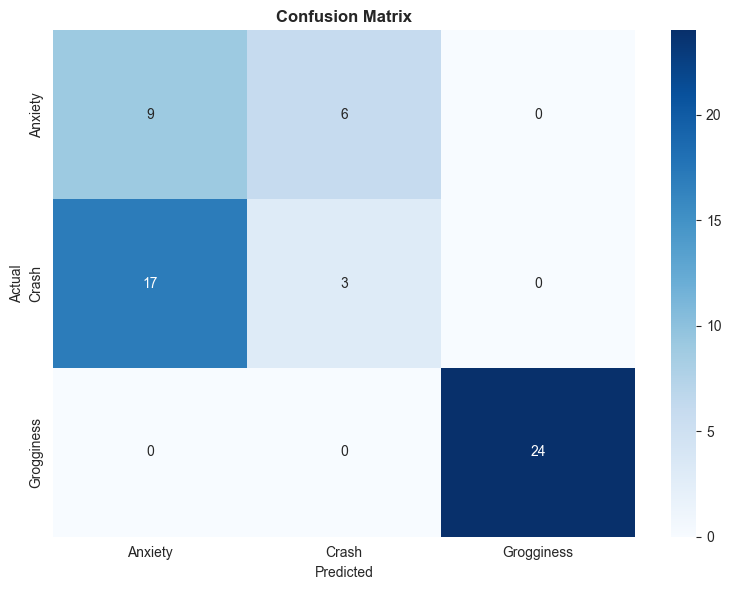

In [36]:
df = df[df["side_effects"] != 3]
print(df.shape)
X = df.drop("side_effects", axis=1)
y = df['side_effects']

scaler, X_train, y_train, X_test, y_test = prepare_train_test(X,y)

grid, best_params, best_score = logistic_model_selection(X_train, y_train)

y_pred = grid.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = grid.score(X_train, y_train)
test_accuracy = grid.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(grid.best_estimator_) #per vedere gli iperparametri scelti

cm = confusion_matrix(y_test, y_pred)
class_labels = ['Anxiety', 'Crash', 'Grogginess']
plot_confusion_matrix(cm, class_labels, title="Confusion Matrix")


Le classi Ansia e Crash sono collassate, coerentemente con il random forest (il che ci sta). Still garbage in garbage out

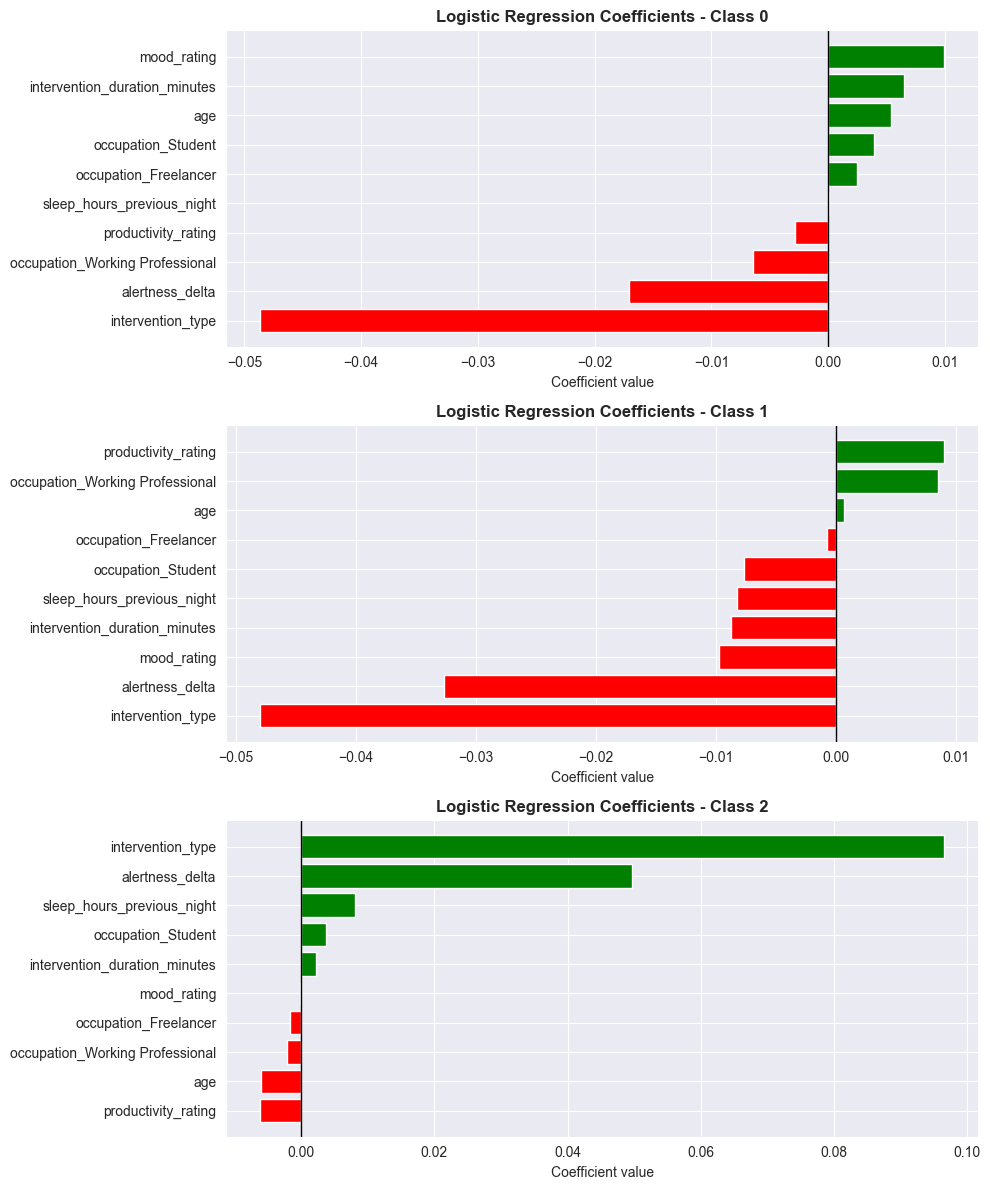

In [37]:
best_model = grid.best_estimator_
X_train_raw = pd.DataFrame(scaler.inverse_transform(X_train), columns=X.columns)
feature_names = X_train_raw.columns
coefs = best_model.coef_
classes = best_model.classes_

plot_logistic_coefficients(coefs, feature_names, classes, figsize_per_class=4)